# ASR Hallucination Detection Ablation Notebook

Main goal:
- use of human-labeled ASR outputs
- detect `hallucination` vs `no_hallucination`
- focus on confidence / uncertainty related signals from ASR outputs
- evaluate with ROC and especially DET behavior



In [1]:
# Install lightweight dependencies for analysis
!pip -q install pandas numpy scikit-learn matplotlib seaborn requests


## 1. Configuration

This cell controls where the notebook gets the label CSV files from.

Default behavior:
- download CSV files from the GitHub repo 
- keeping only CSVs that actually contain usable hallucination labels




In [2]:
from pathlib import Path

USE_GITHUB_REPO = True
GITHUB_OWNER = "GarimaTomar28"
GITHUB_REPO = "first-"
GITHUB_BRANCH = "main"

LOCAL_DATA_DIR = Path("data")
LOCAL_DATA_DIR.mkdir(exist_ok=True)

# Core features already available in your ASR output files
CORE_FEATURES = ["wer", "avg_logprob", "no_speech_prob", "compression_ratio"]

# You can adjust these if needed
TEST_SIZE = 0.30
RANDOM_STATE = 42
MIN_ROWS_FOR_MODELING = 20

print("Using GitHub repo:", USE_GITHUB_REPO)
print("Local data dir:", LOCAL_DATA_DIR.resolve())
print("Core features:", CORE_FEATURES)


Using GitHub repo: True
Local data dir: /content/data
Core features: ['wer', 'avg_logprob', 'no_speech_prob', 'compression_ratio']


## 2. Download or discover the label CSV files

This step pulls all CSV files from the GitHub repo root and saves them locally.

Why this is useful:
- it avoids manually uploading multiple files every time
- it lets the rest of the notebook run in one go
- later cells will automatically ignore files that do not contain valid label information


In [3]:
import requests
import pandas as pd

downloaded_files = []

if USE_GITHUB_REPO:
    api_url = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents?ref={GITHUB_BRANCH}"
    resp = requests.get(api_url, timeout=30)
    resp.raise_for_status()
    repo_items = resp.json()

    for item in repo_items:
        name = item["name"]
        if item["type"] == "file" and name.lower().endswith(".csv"):
            raw_url = item["download_url"]
            out_path = LOCAL_DATA_DIR / name
            file_resp = requests.get(raw_url, timeout=30)
            file_resp.raise_for_status()
            out_path.write_bytes(file_resp.content)
            downloaded_files.append(out_path)

    print("Downloaded CSV files:")
    for f in downloaded_files:
        print("-", f.name)
else:
    downloaded_files = sorted(LOCAL_DATA_DIR.glob("*.csv"))
    print("Using local CSV files:")
    for f in downloaded_files:
        print("-", f.name)


Downloaded CSV files:
- adversarial_labels (2).csv
- commonvoice_annotation_completed .csv
- librispeech_annotation_noisy.csv
- librispeech_labels.csv
- primock_medical_noisy_labels.csv


## 3. Load all candidate CSVs and keep the usable labeled files

A file is considered usable if it contains either:
- `hallucination_binary`, or
- `label_3class`

The notebook also attaches the source filename to each row so you can later see which datasets contributed to the final merged analysis.


In [4]:
candidate_frames = []
load_report = []

for csv_path in sorted(LOCAL_DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(csv_path)
        cols = set(df.columns)
        usable = ("hallucination_binary" in cols) or ("label_3class" in cols)
        load_report.append({
            "file": csv_path.name,
            "rows": len(df),
            "usable_for_labels": usable,
            "columns": list(df.columns),
        })
        if usable:
            df["source_file"] = csv_path.name
            candidate_frames.append(df)
    except Exception as exc:
        load_report.append({
            "file": csv_path.name,
            "rows": None,
            "usable_for_labels": False,
            "columns": [f"ERROR: {exc}"],
        })

load_report_df = pd.DataFrame(load_report)
display(load_report_df[["file", "rows", "usable_for_labels"]])

if not candidate_frames:
    raise ValueError("No usable labeled CSV files were found.")

raw_df = pd.concat(candidate_frames, ignore_index=True)
print("Merged candidate rows:", len(raw_df))
raw_df.head()


,file,rows,usable_for_labels
0,adversarial_labels (2).csv,100,True
1,commonvoice_annotation_completed .csv,73,True
2,librispeech_annotation_noisy.csv,292,True
3,librispeech_labels.csv,100,True
4,primock_medical_noisy_labels.csv,100,True


Merged candidate rows: 665


,dataset,sample_id,reference_text,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,label_3class,hallucination_binary,annotator_id,notes,source_file,meeting_id,speaker,noise_type,snr_db,audio_path
0,adversarial,adv_2961-960-0003,THEY WERE ABSORBED IN HIS THEOLOGY AND WERE UN...,They were absorbed in theology and were under ...,1.000000,-0.489062,0.199341,1.514085,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
1,adversarial,adv_8555-284447-0017,WHEN THIS HAD BEEN ACCOMPLISHED THE BOOLOOROO ...,And he was one of the most popular victims in ...,1.000000,-1.302190,0.182588,1.000000,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
2,adversarial,adv_2300-131720-0005,WHY IF WE ERECT A STATION AT THE FALLS IT IS A...,"Why, if we erect a station at the falls, it is...",1.000000,-0.353160,0.072554,1.112500,Non-Hallucination Error,no_hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
3,adversarial,adv_5142-36377-0022,I WISH YOU GOOD NIGHT SHE LAID HER BONY HANDS ...,I wish you would. Today we're going to hand th...,0.977273,-0.921636,0.340546,1.476510,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
4,adversarial,adv_8455-210777-0040,THEN SAID SIR FERDINANDO THERE IS NOTHING FOR ...,"Then, says Sir Fernando, there is nothing for ...",1.000000,-0.369825,0.079251,1.050000,Non-Hallucination Error,no_hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN


## 4. Clean the labels and build the final binary target

This is the most important preprocessing step.

Rules:
- `Hallucination Error` -> `hallucination`
- `Non-Hallucination Error` -> `no_hallucination`
- `No Error` -> `no_hallucination`

If `hallucination_binary` is already present, we keep it.
If it is missing but `label_3class` exists, we derive it.


In [5]:
import numpy as np

df = raw_df.copy()

if "label_3class" not in df.columns:
    df["label_3class"] = np.nan

if "hallucination_binary" not in df.columns:
    df["hallucination_binary"] = np.nan

df["label_3class"] = df["label_3class"].astype(str).str.strip()
df["hallucination_binary"] = df["hallucination_binary"].astype(str).str.strip().str.lower()

label_map = {
    "Hallucination Error": "hallucination",
    "Non-Hallucination Error": "no_hallucination",
    "No Error": "no_hallucination",
}

missing_binary_mask = ~df["label_3class"].isin(["nan", "None", ""]) & ~df["hallucination_binary"].isin(["hallucination", "no_hallucination"])
df.loc[missing_binary_mask, "hallucination_binary"] = df.loc[missing_binary_mask, "label_3class"].map(label_map)

valid_df = df[df["hallucination_binary"].isin(["hallucination", "no_hallucination"])].copy()
valid_df["y"] = (valid_df["hallucination_binary"] == "hallucination").astype(int)

if valid_df.empty:
    raise ValueError("No valid rows remained after label cleaning.")

print("Usable rows after cleaning:", len(valid_df))
print()
print(valid_df["hallucination_binary"].value_counts())


Usable rows after cleaning: 665

hallucination_binary
no_hallucination    469
hallucination       196
Name: count, dtype: int64


## 5. High-level summary of the merged labeled data

This gives you a quick sense of:
- how many hallucination vs no-hallucination examples you have
- which source files are contributing
- whether the merged set is balanced enough for modeling


In [6]:
display(valid_df["hallucination_binary"].value_counts(dropna=False).rename_axis("class").reset_index(name="count"))

if "dataset" in valid_df.columns:
    print("Counts by dataset and binary label:")
    display(pd.crosstab(valid_df["dataset"], valid_df["hallucination_binary"]))

print("Counts by source file and binary label:")
display(pd.crosstab(valid_df["source_file"], valid_df["hallucination_binary"]))

print("Counts by 3-class label:")
display(valid_df["label_3class"].value_counts(dropna=False).rename_axis("label_3class").reset_index(name="count"))


,class,count
0,no_hallucination,469
1,hallucination,196


Counts by dataset and binary label:


hallucination_binary,hallucination,no_hallucination
dataset,,
adversarial,81,19
commonvoice,17,56
librispeech,0,100
librispeech_fallback,39,253
primock_medical_noisy,59,41


Counts by source file and binary label:


hallucination_binary,hallucination,no_hallucination
source_file,,
adversarial_labels (2).csv,81,19
commonvoice_annotation_completed .csv,17,56
librispeech_annotation_noisy.csv,39,253
librispeech_labels.csv,0,100
primock_medical_noisy_labels.csv,59,41


Counts by 3-class label:


,label_3class,count
0,Non-Hallucination Error,374
1,Hallucination Error,196
2,No Error,95


## 6. Define the feature space

This notebook is centered on the idea:

`Can hallucination be detected from ASR confidence / uncertainty signals?`

So we start from the available uncertainty-related features:
- `avg_logprob`
- `no_speech_prob`
- `compression_ratio`

We also keep `wer` as a comparison feature, because earlier analysis suggested it is useful but not sufficient by itself.


In [7]:
present_features = [c for c in CORE_FEATURES if c in valid_df.columns]
print("Available core features:", present_features)

if len(present_features) < 2:
    raise ValueError("Not enough core features are available to run the ablation study.")

model_df = valid_df[present_features + ["y", "source_file"] + ([ "dataset" ] if "dataset" in valid_df.columns else [])].dropna().copy()

print("Rows available for modeling after dropping missing feature values:", len(model_df))

if len(model_df) < MIN_ROWS_FOR_MODELING:
    raise ValueError(f"Too few rows for modeling. Need at least {MIN_ROWS_FOR_MODELING}, found {len(model_df)}.")

if model_df["y"].nunique() < 2:
    raise ValueError("Only one binary class is present after filtering, so hallucination detection cannot be trained.")

model_df.head()


Available core features: ['wer', 'avg_logprob', 'no_speech_prob', 'compression_ratio']
Rows available for modeling after dropping missing feature values: 665


,wer,avg_logprob,no_speech_prob,compression_ratio,y,source_file,dataset
0,1.000000,-0.489062,0.199341,1.514085,1,adversarial_labels (2).csv,adversarial
1,1.000000,-1.302190,0.182588,1.000000,1,adversarial_labels (2).csv,adversarial
2,1.000000,-0.353160,0.072554,1.112500,0,adversarial_labels (2).csv,adversarial
3,0.977273,-0.921636,0.340546,1.476510,1,adversarial_labels (2).csv,adversarial
4,1.000000,-0.369825,0.079251,1.050000,0,adversarial_labels (2).csv,adversarial


## 7. Train-test split

We use a stratified split so that both classes remain represented in train and test.

Why this matters:
- a normal random split can accidentally skew the class balance
- stratification makes evaluation more stable and fair


In [8]:
from sklearn.model_selection import train_test_split

X = model_df[present_features].copy()
y = model_df["y"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train class counts:")
print(y_train.value_counts())
print("Test class counts:")
print(y_test.value_counts())


Train rows: 465
Test rows: 200
Train class counts:
y
0    328
1    137
Name: count, dtype: int64
Test class counts:
y
0    141
1     59
Name: count, dtype: int64


## 8. Build the ablation list

We generate all non-empty subsets of the available core features.

If all four core features are present, this gives **15 ablations**:
- 4 single-feature models
- 6 two-feature models
- 4 three-feature models
- 1 full model

This part is unfortunately kept short due to the project deadline, it can and will be improved later.

In [9]:
from itertools import combinations

ablation_feature_sets = []
for r in range(1, len(present_features) + 1):
    for combo in combinations(present_features, r):
        ablation_feature_sets.append(list(combo))

print("Total ablations:", len(ablation_feature_sets))
for idx, feats in enumerate(ablation_feature_sets, 1):
    print(f"{idx:02d}. {' + '.join(feats)}")


Total ablations: 15
01. wer
02. avg_logprob
03. no_speech_prob
04. compression_ratio
05. wer + avg_logprob
06. wer + no_speech_prob
07. wer + compression_ratio
08. avg_logprob + no_speech_prob
09. avg_logprob + compression_ratio
10. no_speech_prob + compression_ratio
11. wer + avg_logprob + no_speech_prob
12. wer + avg_logprob + compression_ratio
13. wer + no_speech_prob + compression_ratio
14. avg_logprob + no_speech_prob + compression_ratio
15. wer + avg_logprob + no_speech_prob + compression_ratio


## 9. Run the ablation benchmark

Model choice:
- Logistic Regression

Why:
- simple
- interpretable
- strong enough for feature-based baseline work

For each ablation we compute:
- accuracy
- precision
- recall
- F1
- ROC AUC
- Average Precision
- DET-based best operating point
- minimum `FPR + FNR` as a simple DET-style summary


In [10]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    det_curve,
)

ablation_rows = []
ablation_artifacts = {}

for feature_set in ablation_feature_sets:
    name = " + ".join(feature_set)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])

    clf.fit(X_train[feature_set], y_train)

    y_pred = clf.predict(X_test[feature_set])
    y_score = clf.predict_proba(X_test[feature_set])[:, 1]

    fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
    fpr_det, fnr_det, det_thresholds = det_curve(y_test, y_score)

    det_min_idx = int(np.argmin(fpr_det + fnr_det))

    row = {
        "ablation_name": name,
        "n_features": len(feature_set),
        "features": ", ".join(feature_set),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "avg_precision": average_precision_score(y_test, y_score),
        "det_best_threshold": float(det_thresholds[det_min_idx]) if len(det_thresholds) else np.nan,
        "det_best_fpr": float(fpr_det[det_min_idx]) if len(fpr_det) else np.nan,
        "det_best_fnr": float(fnr_det[det_min_idx]) if len(fnr_det) else np.nan,
        "det_fpr_plus_fnr": float((fpr_det + fnr_det)[det_min_idx]) if len(fpr_det) else np.nan,
    }
    ablation_rows.append(row)

    ablation_artifacts[name] = {
        "clf": clf,
        "feature_set": feature_set,
        "y_pred": y_pred,
        "y_score": y_score,
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "fpr_det": fpr_det,
        "fnr_det": fnr_det,
        "det_thresholds": det_thresholds,
    }

results_df = pd.DataFrame(ablation_rows)
results_df = results_df.sort_values(
    ["det_fpr_plus_fnr", "roc_auc", "f1"],
    ascending=[True, False, False]
).reset_index(drop=True)

display(results_df.round(4))


,ablation_name,n_features,features,accuracy,precision,recall,f1,roc_auc,avg_precision,det_best_threshold,det_best_fpr,det_best_fnr,det_fpr_plus_fnr
0,wer + avg_logprob + compression_ratio,3,"wer, avg_logprob, compression_ratio",0.810,0.6721,0.6949,0.6833,0.8235,0.7405,0.5494,0.0496,0.3220,0.3717
1,avg_logprob + no_speech_prob + compression_ratio,3,"avg_logprob, no_speech_prob, compression_ratio",0.835,0.7321,0.6949,0.7130,0.8012,0.6742,0.4916,0.1064,0.2881,0.3945
2,wer + avg_logprob + no_speech_prob + compressi...,4,"wer, avg_logprob, no_speech_prob, compression_...",0.825,0.7143,0.6780,0.6957,0.8459,0.7199,0.6243,0.0567,0.3390,0.3957
3,no_speech_prob,1,no_speech_prob,0.825,0.7222,0.6610,0.6903,0.7509,0.6152,0.4472,0.1135,0.3051,0.4186
4,avg_logprob + no_speech_prob,2,"avg_logprob, no_speech_prob",0.830,0.7193,0.6949,0.7069,0.7406,0.6521,0.5131,0.1135,0.3051,0.4186
5,avg_logprob + compression_ratio,2,"avg_logprob, compression_ratio",0.800,0.6557,0.6780,0.6667,0.8084,0.7242,0.5767,0.0993,0.3220,0.4213
6,wer + avg_logprob + no_speech_prob,3,"wer, avg_logprob, no_speech_prob",0.825,0.7308,0.6441,0.6847,0.7777,0.6872,0.5983,0.0709,0.3559,0.4269
7,no_speech_prob + compression_ratio,2,"no_speech_prob, compression_ratio",0.795,0.6800,0.5763,0.6239,0.8184,0.6437,0.4423,0.1348,0.3051,0.4398
8,wer + no_speech_prob,2,"wer, no_speech_prob",0.825,0.7308,0.6441,0.6847,0.7888,0.6832,0.5679,0.0851,0.3559,0.4410
9,wer + no_speech_prob + compression_ratio,3,"wer, no_speech_prob, compression_ratio",0.815,0.6964,0.6610,0.6783,0.8442,0.6945,0.5063,0.1135,0.3390,0.4525


## 10. Save the ablation table



In [11]:
results_path = Path("ablation_results.csv")
results_df.to_csv(results_path, index=False)
print("Saved ablation table to:", results_path.resolve())


Saved ablation table to: /content/ablation_results.csv


## 11. DET curves for the top ablations

Because the project focus explicitly mentions DET-based detection, this plot is one of the most important outputs.

Interpretation:
- lower-left is better
- lower false positive rate and lower false negative rate is the goal


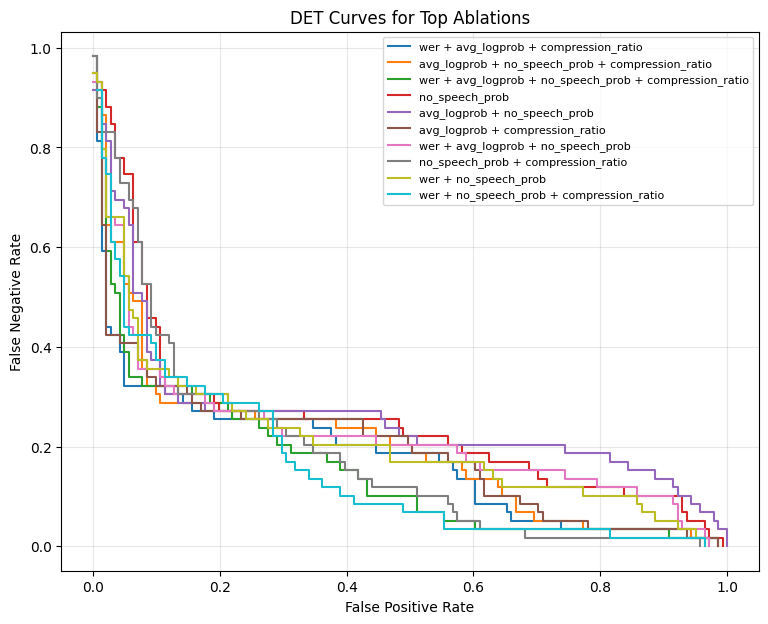

In [12]:
top_k = min(10, len(results_df))
top_names = results_df.head(top_k)["ablation_name"].tolist()

plt.figure(figsize=(9, 7))
for name in top_names:
    art = ablation_artifacts[name]
    plt.plot(art["fpr_det"], art["fnr_det"], label=name)

plt.xlabel("False Positive Rate")
plt.ylabel("False Negative Rate")
plt.title("DET Curves for Top Ablations")
plt.legend(fontsize=8, loc="best")
plt.grid(True, alpha=0.3)
plt.show()


## 12. ROC curves for the top ablations

This is useful as a complementary view to the DET curves.


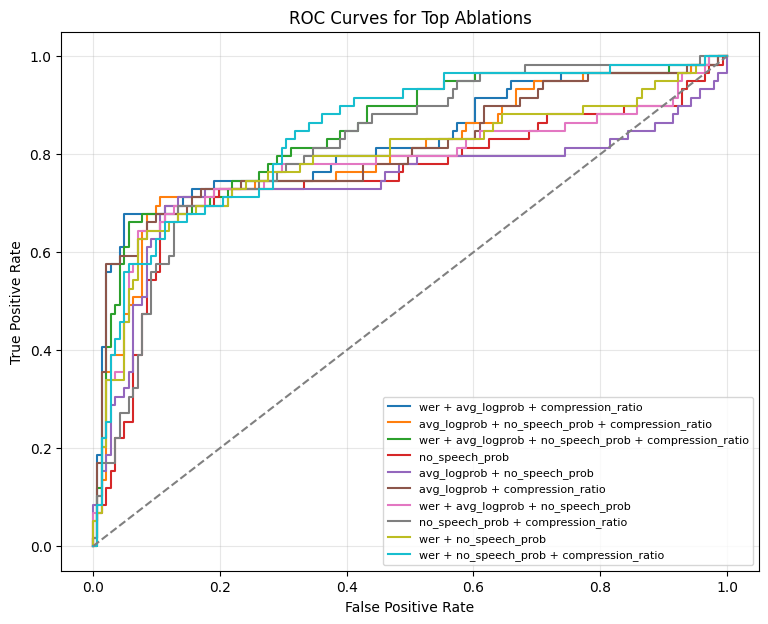

In [13]:
plt.figure(figsize=(9, 7))
for name in top_names:
    art = ablation_artifacts[name]
    plt.plot(art["fpr"], art["tpr"], label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Top Ablations")
plt.legend(fontsize=8, loc="best")
plt.grid(True, alpha=0.3)
plt.show()


## 13. Pick the best ablation and inspect it closely

Selection rule:
- best by lowest `DET FPR + FNR`
- then highest ROC AUC

This keeps the choice aligned with the project's DET-based principle.


In [14]:
best_row = results_df.iloc[0]
best_name = best_row["ablation_name"]
best_features = ablation_artifacts[best_name]["feature_set"]
best_clf = ablation_artifacts[best_name]["clf"]
best_y_pred = ablation_artifacts[best_name]["y_pred"]
best_y_score = ablation_artifacts[best_name]["y_score"]

print("Best ablation:", best_name)
print("Features:", best_features)
display(best_row.to_frame("value"))


Best ablation: wer + avg_logprob + compression_ratio
Features: ['wer', 'avg_logprob', 'compression_ratio']


,value
ablation_name,wer + avg_logprob + compression_ratio
n_features,3
features,"wer, avg_logprob, compression_ratio"
accuracy,0.81
precision,0.672131
recall,0.694915
f1,0.683333
roc_auc,0.823536
avg_precision,0.7405
det_best_threshold,0.549434


## 14. Confusion matrix and classification report for the best model

This gives you the most report-ready classification summary.


Confusion matrix:
[[121  20]
 [ 18  41]]

Classification report:
              precision    recall  f1-score   support

           0     0.8705    0.8582    0.8643       141
           1     0.6721    0.6949    0.6833        59

    accuracy                         0.8100       200
   macro avg     0.7713    0.7765    0.7738       200
weighted avg     0.8120    0.8100    0.8109       200



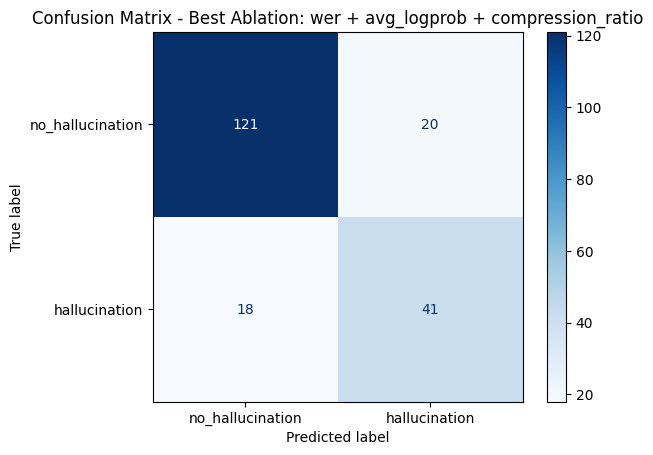

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, best_y_pred)
print("Confusion matrix:")
print(cm)
print()
print("Classification report:")
print(classification_report(y_test, best_y_pred, digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no_hallucination", "hallucination"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - Best Ablation: {best_name}")
plt.show()


## 15. Coefficient analysis for the best logistic-regression model

This helps answer:
- which features push predictions toward hallucination?
- which features push predictions toward no_hallucination?


,feature,coefficient
2,compression_ratio,1.722613
0,wer,0.248862
1,avg_logprob,-0.986821


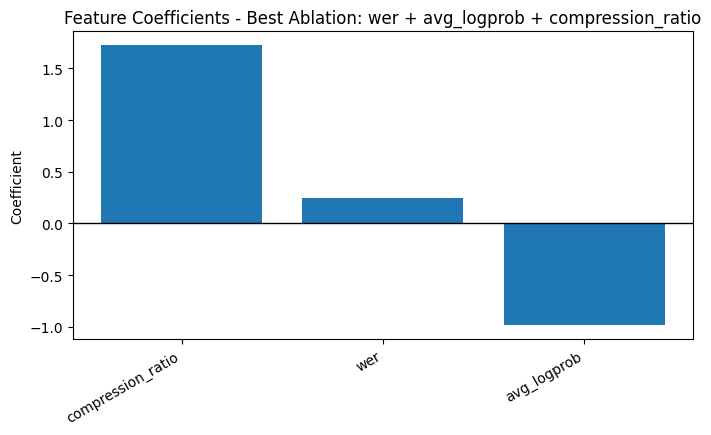

In [16]:
best_model = best_clf.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": best_features,
    "coefficient": best_model.coef_[0],
}).sort_values("coefficient", ascending=False)

display(coef_df)

plt.figure(figsize=(8, 4))
plt.bar(coef_df["feature"], coef_df["coefficient"])
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Feature Coefficients - Best Ablation: {best_name}")
plt.ylabel("Coefficient")
plt.xticks(rotation=30, ha="right")
plt.show()


## 16. Error analysis

This cell shows the false positives and false negatives from the best model.

Using this for:
- checking whether the detector is confusing normal errors with hallucinations
- extracting qualitative examples for the final report


In [17]:
test_rows = X_test.index
inspect_df = valid_df.loc[test_rows].copy()
inspect_df["true"] = y_test.values
inspect_df["pred"] = best_y_pred
inspect_df["score"] = best_y_score

mistakes_df = inspect_df[inspect_df["true"] != inspect_df["pred"]].copy()

print("Mistake count:", len(mistakes_df))

cols_to_show = [c for c in [
    "source_file", "dataset", "sample_id", "reference_text", "pred_text",
    "label_3class", "hallucination_binary", "wer", "avg_logprob",
    "no_speech_prob", "compression_ratio", "true", "pred", "score"
] if c in mistakes_df.columns]

display(mistakes_df[cols_to_show].sort_values("score", ascending=False).head(30))


Mistake count: 38


,source_file,dataset,sample_id,reference_text,pred_text,label_3class,hallucination_binary,wer,avg_logprob,no_speech_prob,compression_ratio,true,pred,score
584,primock_medical_noisy_labels.csv,primock_medical_noisy,mednoisy_day3_consultation02_patient,"Hi. Yep, uh, John Doe. Uhh, twenty-one twelve ...",Hi. John Doe. I am 21121986. number one London...,Non-Hallucination Error,no_hallucination,0.805128,-0.427578,0.515329,3.910652,0,1,0.999817
645,primock_medical_noisy_labels.csv,primock_medical_noisy,mednoisy_day2_consultation06_patient,"Hello. Good morning. Hi, . Yeah, sure. Um, my ...","Hello. Good morning. Hi, how are you? Hello. Y...",Non-Hallucination Error,no_hallucination,0.529289,-0.568518,0.351179,1.866720,0,1,0.915847
626,primock_medical_noisy_labels.csv,primock_medical_noisy,mednoisy_day1_consultation07_patient,"Hello? Yes, yeah I can, I can, cheers. Uh, I a...","Hello? Yes, yeah, I can. I can choose. I am no...",Non-Hallucination Error,no_hallucination,0.532571,-0.434455,0.535596,1.687145,0,1,0.767049
558,librispeech_labels.csv,librispeech,2961-960-0000,HE PASSES ABRUPTLY FROM PERSONS TO IDEAS AND N...,He passes abruptly from persons to ideas and n...,No Error,no_hallucination,1.000000,-0.224484,0.103417,1.653846,0,1,0.664385
56,adversarial_labels (2).csv,adversarial,adv_1320-122617-0002,IN OTHER WORDS WHILE HE HAD IMPLICIT FAITH IN ...,"In other words, while he had implicit faith in...",Non-Hallucination Error,no_hallucination,1.022727,-0.335405,0.052764,1.438272,0,1,0.631663
196,librispeech_annotation_noisy.csv,librispeech_fallback,ls_0005__babble_10dB,HAVING RETURNED TO THE ROYAL CAVERN KALIKO FIR...,"Having returned to the Royal Cavern, Calico fi...",Non-Hallucination Error,no_hallucination,1.000000,-0.321527,0.028625,1.459459,0,1,0.625807
29,adversarial_labels (2).csv,adversarial,adv_6829-68769-0032,I DISCOVERED AND PUT OUT A FIRE THAT WOULD HAV...,I discovered and put out a fire that would hav...,Non-Hallucination Error,no_hallucination,0.950000,-0.503681,0.131333,1.170213,0,1,0.593331
648,primock_medical_noisy_labels.csv,primock_medical_noisy,mednoisy_day5_consultation04_doctor,"Hello. Hello, I'm Doctor Smith from Babylon. H...","Hello, I'm Dr Smith from Babylon. Hi there, ca...",No Error,no_hallucination,0.411082,-0.489472,0.218551,1.338439,0,1,0.545787
588,primock_medical_noisy_labels.csv,primock_medical_noisy,mednoisy_day2_consultation01_patient,"Yep. Can you find Uh yeah, uh Jack Smith, uh t...",Can you find? Jack Smith 31st October 1990 I a...,Non-Hallucination Error,no_hallucination,0.452107,-0.582733,0.388355,1.185744,0,1,0.545209
330,librispeech_annotation_noisy.csv,librispeech_fallback,ls_0039__white_10dB,BECAUSE YOU WERE SLEEPING INSTEAD OF CONQUERIN...,Because you were sleeping instead of conquerin...,Non-Hallucination Error,no_hallucination,1.000000,-0.397875,0.030482,1.241667,0,1,0.543456


## 17. Save best-model predictions and mistakes



In [18]:
pred_out = inspect_df.copy()
pred_out_path = Path("best_model_test_predictions.csv")
pred_out.to_csv(pred_out_path, index=False)

mistakes_out_path = Path("best_model_mistakes.csv")
mistakes_df.to_csv(mistakes_out_path, index=False)

print("Saved:")
print("-", pred_out_path.resolve())
print("-", mistakes_out_path.resolve())


Saved:
- /content/best_model_test_predictions.csv
- /content/best_model_mistakes.csv


## 18. Short automated write-up for your report

This cell creates a compact text summary of the ablation study.


In [19]:
summary_lines = []
summary_lines.append("# Hallucination Detection Ablation Summary")
summary_lines.append("")
summary_lines.append(f"Total usable labeled rows: {len(valid_df)}")
summary_lines.append(f"Modeling rows after dropping missing values: {len(model_df)}")
summary_lines.append("")
summary_lines.append("## Class balance")
for k, v in valid_df["hallucination_binary"].value_counts().items():
    summary_lines.append(f"- {k}: {v}")
summary_lines.append("")
summary_lines.append("## Best ablation")
summary_lines.append(f"- Name: {best_name}")
summary_lines.append(f"- Features: {', '.join(best_features)}")
summary_lines.append(f"- Accuracy: {best_row['accuracy']:.4f}")
summary_lines.append(f"- Precision: {best_row['precision']:.4f}")
summary_lines.append(f"- Recall: {best_row['recall']:.4f}")
summary_lines.append(f"- F1: {best_row['f1']:.4f}")
summary_lines.append(f"- ROC AUC: {best_row['roc_auc']:.4f}")
summary_lines.append(f"- Average Precision: {best_row['avg_precision']:.4f}")
summary_lines.append(f"- DET best FPR: {best_row['det_best_fpr']:.4f}")
summary_lines.append(f"- DET best FNR: {best_row['det_best_fnr']:.4f}")
summary_lines.append(f"- DET FPR+FNR: {best_row['det_fpr_plus_fnr']:.4f}")
summary_lines.append("")
summary_lines.append("## Coefficient interpretation")
for _, row in coef_df.iterrows():
    direction = "toward hallucination" if row["coefficient"] > 0 else "toward no_hallucination"
    summary_lines.append(f"- {row['feature']}: {row['coefficient']:.4f} ({direction})")

summary_text = "\n".join(summary_lines)
summary_path = Path("ablation_summary.md")
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print()
print("Saved summary to:", summary_path.resolve())


# Hallucination Detection Ablation Summary

Total usable labeled rows: 665
Modeling rows after dropping missing values: 665

## Class balance
- no_hallucination: 469
- hallucination: 196

## Best ablation
- Name: wer + avg_logprob + compression_ratio
- Features: wer, avg_logprob, compression_ratio
- Accuracy: 0.8100
- Precision: 0.6721
- Recall: 0.6949
- F1: 0.6833
- ROC AUC: 0.8235
- Average Precision: 0.7405
- DET best FPR: 0.0496
- DET best FNR: 0.3220
- DET FPR+FNR: 0.3717

## Coefficient interpretation
- compression_ratio: 1.7226 (toward hallucination)
- wer: 0.2489 (toward hallucination)
- avg_logprob: -0.9868 (toward no_hallucination)

Saved summary to: /content/ablation_summary.md


In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

readme_lines = []

readme_lines.append("# ASR Hallucination Detection Report")
readme_lines.append("")
readme_lines.append("## Overview")
readme_lines.append(
    "This report summarizes the hallucination detection experiments run on the merged human-labeled ASR outputs."
)
readme_lines.append(
    "The goal was to test whether confidence- and uncertainty-related ASR signals can help distinguish hallucinated outputs from non-hallucinated outputs."
)
readme_lines.append("")

readme_lines.append("## Dataset Summary")
readme_lines.append(f"- Total usable labeled rows: {len(valid_df)}")
readme_lines.append(f"- Rows used for modeling after dropping missing feature values: {len(model_df)}")
readme_lines.append("")

readme_lines.append("### Binary Label Distribution")
for label, count in valid_df["hallucination_binary"].value_counts().items():
    pct = 100 * count / len(valid_df)
    readme_lines.append(f"- {label}: {count} ({pct:.2f}%)")
readme_lines.append("")

if "dataset" in valid_df.columns:
    readme_lines.append("### Dataset Distribution")
    dataset_counts = valid_df["dataset"].value_counts()
    for ds, count in dataset_counts.items():
        readme_lines.append(f"- {ds}: {count}")
    readme_lines.append("")

readme_lines.append("## Ablation Study")
readme_lines.append(
    f"A total of {len(results_df)} feature ablations were evaluated using logistic regression."
)
readme_lines.append(
    "Each ablation was scored using accuracy, precision, recall, F1, ROC AUC, average precision, and DET-based operating point summaries."
)
readme_lines.append("")

readme_lines.append("### Best Performing Ablation")
readme_lines.append(f"- Name: {best_name}")
readme_lines.append(f"- Features used: {', '.join(best_features)}")
readme_lines.append(f"- Accuracy: {best_row['accuracy']:.4f}")
readme_lines.append(f"- Precision: {best_row['precision']:.4f}")
readme_lines.append(f"- Recall: {best_row['recall']:.4f}")
readme_lines.append(f"- F1 score: {best_row['f1']:.4f}")
readme_lines.append(f"- ROC AUC: {best_row['roc_auc']:.4f}")
readme_lines.append(f"- Average Precision: {best_row['avg_precision']:.4f}")
readme_lines.append(f"- DET best threshold: {best_row['det_best_threshold']:.4f}")
readme_lines.append(f"- DET best false positive rate: {best_row['det_best_fpr']:.4f}")
readme_lines.append(f"- DET best false negative rate: {best_row['det_best_fnr']:.4f}")
readme_lines.append(f"- DET best FPR + FNR: {best_row['det_fpr_plus_fnr']:.4f}")
readme_lines.append("")

readme_lines.append("## ROC Curve Interpretation")
readme_lines.append(
    f"The best model achieved an ROC AUC of {best_row['roc_auc']:.4f}, which indicates how well the detector ranks hallucination samples above non-hallucination samples across thresholds."
)
if best_row["roc_auc"] >= 0.9:
    readme_lines.append(
        "This suggests very strong class discrimination for the current labeled dataset."
    )
elif best_row["roc_auc"] >= 0.8:
    readme_lines.append(
        "This suggests good class discrimination for the current labeled dataset."
    )
elif best_row["roc_auc"] >= 0.7:
    readme_lines.append(
        "This suggests moderate but useful discrimination for the current labeled dataset."
    )
else:
    readme_lines.append(
        "This suggests limited discrimination, meaning the selected features only weakly separate the two classes."
    )
readme_lines.append("")

readme_lines.append("## DET Curve Interpretation")
readme_lines.append(
    "The DET curve was used to study the tradeoff between false positives and false negatives."
)
readme_lines.append(
    f"For the best ablation, the lowest observed FPR + FNR occurred at threshold {best_row['det_best_threshold']:.4f}, with FPR = {best_row['det_best_fpr']:.4f} and FNR = {best_row['det_best_fnr']:.4f}."
)
readme_lines.append(
    "A lower DET operating point is preferable because it means the detector misses fewer hallucinations while also producing fewer false alarms."
)
readme_lines.append("")

readme_lines.append("## Confusion Matrix and Classification Behavior")
readme_lines.append("Confusion matrix:")
readme_lines.append("```text")
readme_lines.append(str(cm))
readme_lines.append("```")
readme_lines.append("")
readme_lines.append("Classification report:")
readme_lines.append("```text")
readme_lines.append(classification_report(y_test, best_y_pred, digits=4))
readme_lines.append("```")
readme_lines.append("")

readme_lines.append("## Feature Importance Interpretation")
readme_lines.append(
    "For the best logistic-regression model, the learned coefficients show which features push predictions toward hallucination versus no_hallucination."
)
for _, row in coef_df.iterrows():
    direction = "toward hallucination" if row["coefficient"] > 0 else "toward no_hallucination"
    readme_lines.append(f"- {row['feature']}: {row['coefficient']:.4f} ({direction})")
readme_lines.append("")

readme_lines.append("## What the Results Suggest")
if len(coef_df) > 0:
    top_positive = coef_df.iloc[0]
    top_negative = coef_df.iloc[-1]
    readme_lines.append(
        f"- The strongest positive signal for hallucination in the best model was `{top_positive['feature']}`."
    )
    readme_lines.append(
        f"- The strongest feature associated with the no_hallucination side was `{top_negative['feature']}`."
    )
readme_lines.append(
    "- Overall, the ablation study helps identify whether hallucination detection is driven more by confidence-related ASR signals, lexical error measures, or their combination."
)
readme_lines.append("")

readme_lines.append("## Error Analysis")
readme_lines.append(f"- Number of mistakes made by the best model on the test set: {len(mistakes_df)}")
if len(mistakes_df) > 0:
    false_pos = ((mistakes_df["true"] == 0) & (mistakes_df["pred"] == 1)).sum()
    false_neg = ((mistakes_df["true"] == 1) & (mistakes_df["pred"] == 0)).sum()
    readme_lines.append(f"- False positives: {false_pos}")
    readme_lines.append(f"- False negatives: {false_neg}")
    readme_lines.append(
        "- Reviewing these mistakes is useful for checking whether the detector is confusing ordinary ASR difficulty with true hallucination behavior."
    )
readme_lines.append("")

readme_lines.append("## Limitations")
readme_lines.append(
    "- The detector is only as reliable as the currently available human-labeled dataset."
)
readme_lines.append(
    "- Strong performance on this merged set does not automatically guarantee generalization to unseen datasets or different ASR architectures."
)
readme_lines.append(
    "- Confidence-related features may also respond to general acoustic difficulty, so some of the signal may reflect uncertainty more broadly rather than hallucination alone."
)
readme_lines.append("")

readme_lines.append("## Final Takeaway")
readme_lines.append(
    "The current ablation study shows that hallucination detection from ASR-side uncertainty features is feasible on the labeled dataset, and the DET-based analysis helps identify the most practically useful operating points."
)
readme_lines.append(
    "The best-performing feature set should be treated as the strongest current baseline for the final report."
)
readme_lines.append("")

readme_text = "\n".join(readme_lines)

readme_path = Path("hallucination_detection_report_README.md")
readme_path.write_text(readme_text, encoding="utf-8")

print("Saved README to:", readme_path.resolve())
print()
print(readme_text[:4000])


Saved README to: /content/hallucination_detection_report_README.md

# ASR Hallucination Detection Report

## Overview
This report summarizes the hallucination detection experiments run on the merged human-labeled ASR outputs.
The goal was to test whether confidence- and uncertainty-related ASR signals can help distinguish hallucinated outputs from non-hallucinated outputs.

## Dataset Summary
- Total usable labeled rows: 665
- Rows used for modeling after dropping missing feature values: 665

### Binary Label Distribution
- no_hallucination: 469 (70.53%)
- hallucination: 196 (29.47%)

### Dataset Distribution
- librispeech_fallback: 292
- adversarial: 100
- librispeech: 100
- primock_medical_noisy: 100
- commonvoice: 73

## Ablation Study
A total of 15 feature ablations were evaluated using logistic regression.
Each ablation was scored using accuracy, precision, recall, F1, ROC AUC, average precision, and DET-based operating point summaries.

### Best Performing Ablation
- Name: wer + 